## Test WP_calib class

In [1]:
import sys
sys.path.append(r"/home/bausciadaq/BAWSHA/src/process/VPhi")
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import linregress
from WP_calib import Fitter

In [3]:
folder_path = r"/home/bausciadaq/Run6/DAQ/TempScans/"
#file = folder_path + "Vphi_cooldown_highT_WP.hdf5"
file = folder_path + "Vphi_cooldown_highT_WP_averagedtraces.hdf5"

fit = Fitter(data_path=file)

In [4]:
#fit.get_acq_from_date()
fit.get_last_acq()

Loading last group 'acq_0077_2026-05-26_17-36-25':
    |- Flux: shape=(20000,), dtype=float64
    |- Time: shape=(20000,), dtype=float64
    |- Volt: shape=(20000,), dtype=float64


In [5]:
fit.find_monitor_crossings()

Periodi disponibili   : 1
Zero-crossing trovati : 5


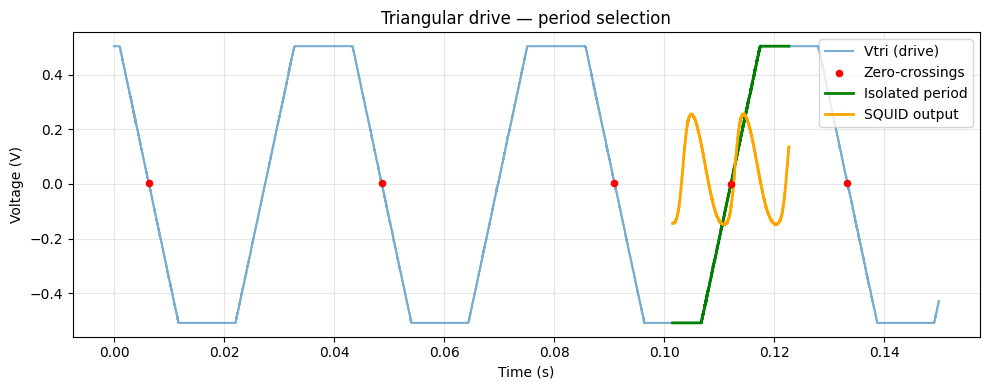

In [ ]:
fit.find_monitor_crossings()

In [7]:
fit.find_squid_crossings()

In [8]:
fit.find_vout_zero_crossing()

Crossing index 1409
Nsym  26
Fit window: ±26 samples around time 0.010517499999999999 (total 53 pts out of 1068)

── Fit results ──────────────────────────────────────────
  Points used   : 53  (indices 1383:1435)
  Slope         : 1.0265  V/Phi_0
  Intercept     : -14.457147 V
  R²            : 0.978608
  Std err slope : 2.6531 V/Phi_0
  Period [s]    : 0.0080 
  2000 Vphi      : 1.026492501209483


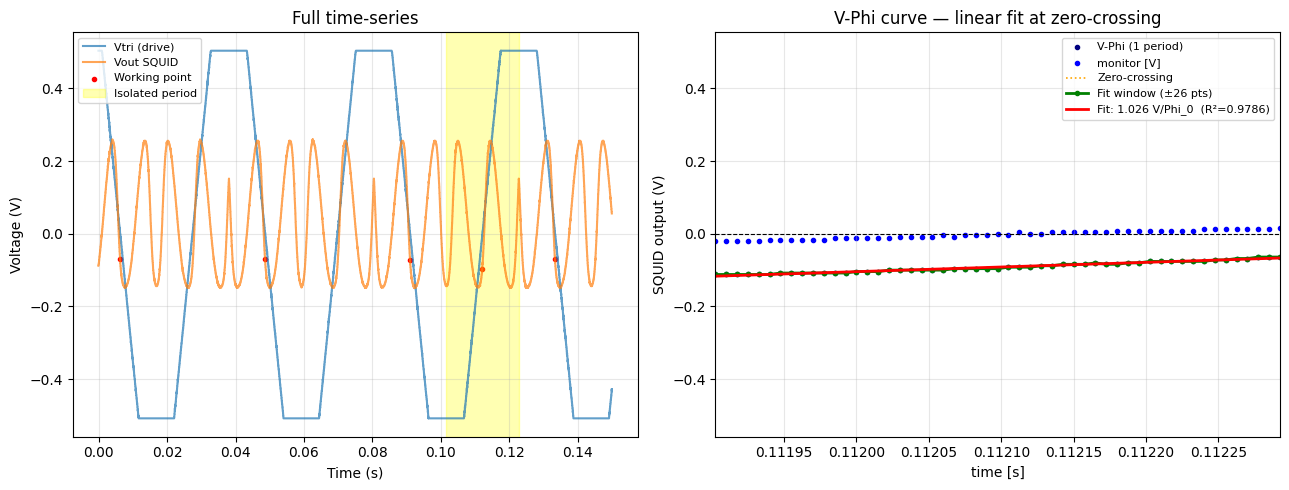

In [9]:

fit.linear_fit(verbose=1)

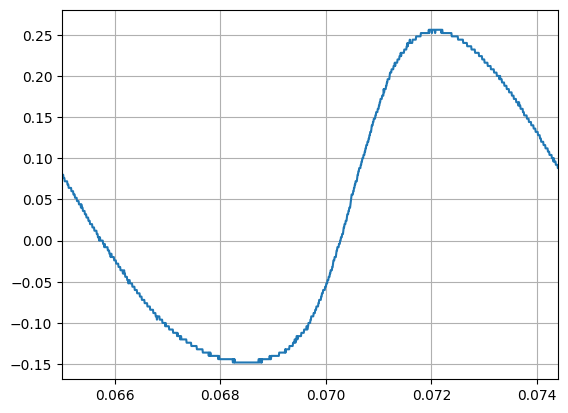

In [10]:
plt.plot(fit.time, fit.squid)
plt.xlim(0.065, 0.0744)
plt.grid()

## Compute $\overline{V_{\Phi}} = \frac{1}{N_{\text{period}}}\sum_{i=1}^{N_{\text{period}}} {V_{\Phi}}_i$

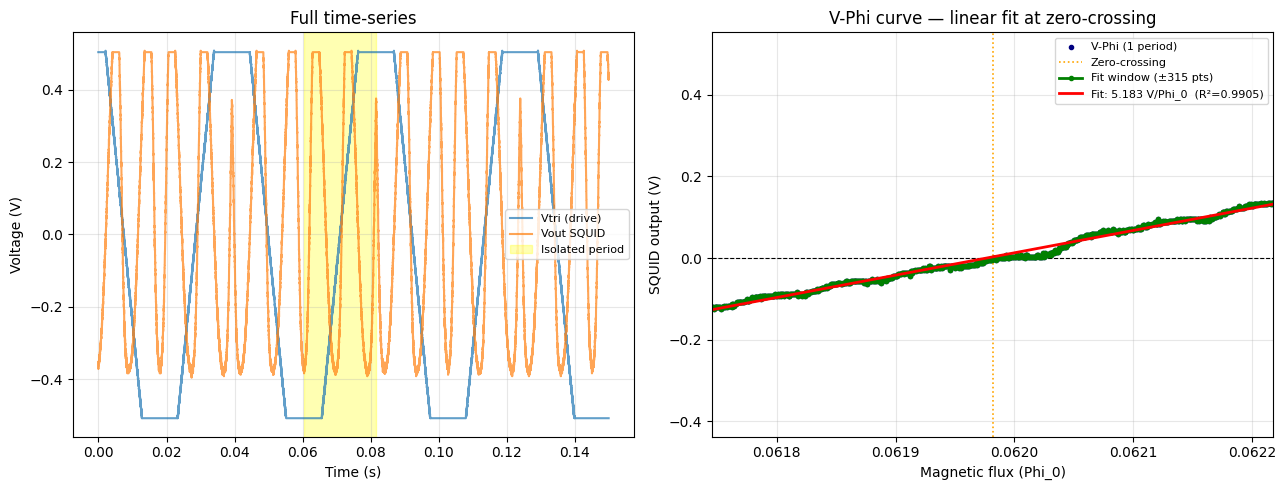

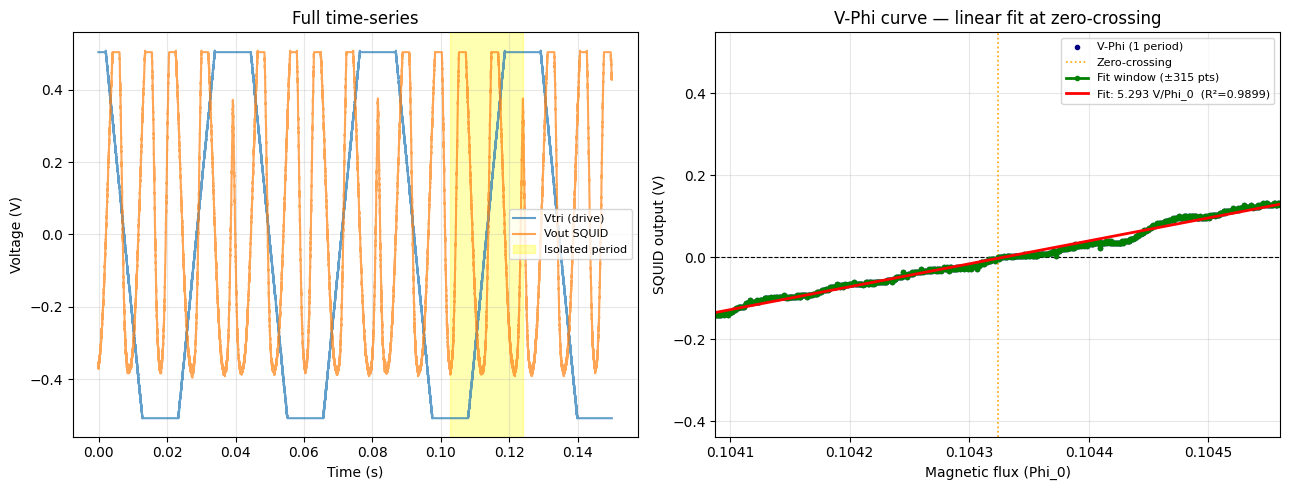


── Multi-period summary ─────────────────────────────────
  Periods fitted  : 2
  Mean slope      : 5.2377 V/Phi_0
  Std slope       : 0.0551 V/Phi_0
  Mean R²         : 0.9902


In [ ]:
i1_start = 2
i2_start = 3
i3_start = 4

slopes     = []
intercepts = []
r_squared  = []
std_errs   = []

for n in range(fit.N_periods):
    fit.select_raise(i1=i1_start + 2*n, i2=i2_start + 2*n, i3=i3_start + 2*n, plot=False)
    fit.find_squid_crossings()
    fit.find_vout_zero_crossing()
    fit.linear_fit(verbose=0, diagnostic_plot=True)

    slopes.append(fit.slope)
    intercepts.append(fit.intercept)
    r_squared.append(fit.r_squared)
    std_errs.append(fit.std_err*fit.T_period)

slopes     = np.array(slopes)
intercepts = np.array(intercepts)
r_squared  = np.array(r_squared)
std_errs   = np.array(std_errs)

print(f"\n── Multi-period summary ─────────────────────────────────")
print(f"  Periods fitted  : {len(slopes)}")
print(f"  Mean slope      : {np.mean(slopes):.4f} V/Phi_0")
print(f"  Std slope       : {np.std(slopes):.4f} V/Phi_0")
print(f"  Mean R²         : {np.mean(r_squared):.4f}")

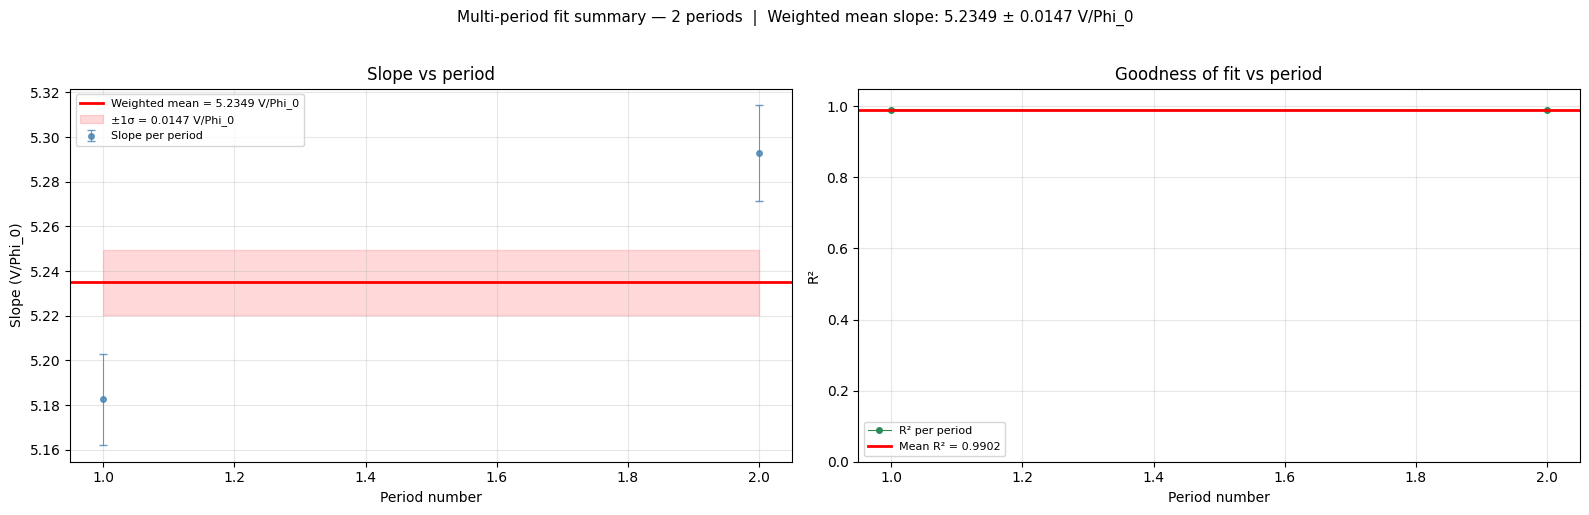


── Weighted fit summary ─────────────────────────────────
  Periods fitted       : 2
  Weighted mean slope  : 5.2349 V/Phi_0
  Weighted std slope   : 0.0147 V/Phi_0


In [13]:
fit.plot_fit_results(slopes, intercepts, r_squared, std_errs)

# Open all files of temperature sweep

In [10]:
import sys
sys.path.append(r"/home/bausciadaq/BAWSHA/src/process/VPhi")
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import linregress
from WP_calib import Fitter

In [11]:
folder_path = r"/home/bausciadaq/Run6/DAQ/TempScans/"
#file = folder_path + "Vphi_cooldown_highT_WP.hdf5"
file = folder_path + "Vphi_cooldown_highT_WP_averagedtraces.hdf5"

fit = Fitter(data_path=file)

In [20]:
temps = []
Vphis = []
sigma_Vphis = []
Periods=[]

with h5.File(fit.file_path, "r") as f:
    groups = list(f.keys())
    if not groups:
        raise ValueError(f"No groups found in {fit.file_path}.")

    for g, group in enumerate(groups):
        if g % 1 == 0:
            print(f"Loading group: ", group)
            data = f[group]
            fit.time    = data["Time"][:]
            fit.monitor = data["Flux"][:]        ########!!!!!!!
            fit.squid   = data["Volt"][:]
            fit.find_monitor_crossings()
        
            fit.select_raise(i1=0, i2=1, i3=2, plot=False, first=True)
            fit.find_squid_crossings()
            fit.find_vout_zero_crossing()
            #fit.plot_period()
            fit.linear_fit(verbose=1, diagnostic_plot=False, n_pts=50)
            tempcp = data.attrs["T_coldplate_mK"]
            vphi1 = fit.conversion
            sigma_vphi1 = fit.sigma_conversion
            period1 = fit.T_period
            print(f"Cold plate temperature = {tempcp:.0f} mK")

            
            fit.select_raise(i1=0, i2=1, i3=2, plot=False, second=True)
            fit.find_squid_crossings()
            fit.find_vout_zero_crossing()
            #fit.plot_period()

            fit.linear_fit(verbose=1, diagnostic_plot=False, n_pts=50)

            vphi2 = fit.conversion
            sigma_vphi2 = fit.sigma_conversion
            period2 = fit.T_period


            fit.select_raise(i1=0, i2=1, i3=2, plot=False, third=True)
            fit.find_squid_crossings()
            fit.find_vout_zero_crossing()
            #fit.plot_period()
            fit.linear_fit(verbose=1, diagnostic_plot=False, n_pts=50)
            vphi3 = fit.conversion
            sigma_vphi3 = fit.sigma_conversion
            period3 = fit.T_period
            periods = [period1, period2, period3]
            print (f"Temp {tempcp:.0f}; Vphi = {vphi1:.3f} {vphi2:.3f} {vphi3:.3f} ")
            vphis = np.array([vphi1, vphi2, vphi3])
            temps.append(tempcp)
            Vphis.append(np.average(vphis))
            sigma_Vphis.append(np.std(vphis))
            Periods.append(np.average(periods))


Loading group:  acq_0000_2026-05-26_16-40-33
Available periods     : 2
Crossings found       : 3
Mean period [samples] : 5649
Backward offset=1: T=4.4400 ms out of [8.0, 11.0] ms, skipping.
NOTE: skipped 1 spurious crossing(s) before anchor, used offset=2 for backward period.
Forward offset=1: T=5.0400 ms out of [8.0, 11.0] ms, skipping.
NOTE: skipped 1 spurious crossing(s) after anchor, used offset=2 for forward period.
Anchor crossing       : index 2810, t = 0.027377 s
T_backward [ms]       : 9.4500
T_forward  [ms]       : 9.5025
Consistency           : 0.55% difference
T_period   [ms]       : 9.4763
Crossing index 2824
Nsym  50
Fit window: ±50 samples around time 0.0 (total 101 pts out of 1263)

── Fit results ──────────────────────────────────────────
  Points used   : 101  (indices 2774:2874)
  Intercept     : -5.841939 V
  Period [s]    : 0.0095 
  2000 Vphi      : 2.0210112987769406 V / Phi0 ± 0.01558219921006651
Cold plate temperature = 1418 mK
Forward offset=1: T=5.0250 ms out

Text(0, 0.5, '2000 Vphi [V / Phi0]')

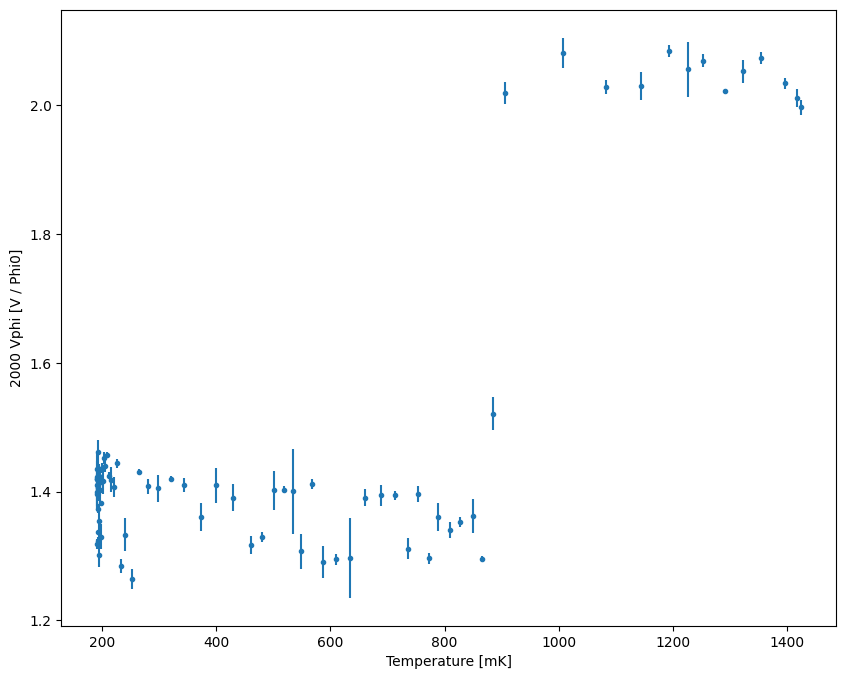

In [17]:
plt.figure(figsize=(10,8))
plt.errorbar(temps, Vphis, yerr = sigma_Vphis, linestyle='', marker='.')
plt.xlabel("Temperature [mK]")
plt.ylabel("2000 Vphi [V / Phi0]")

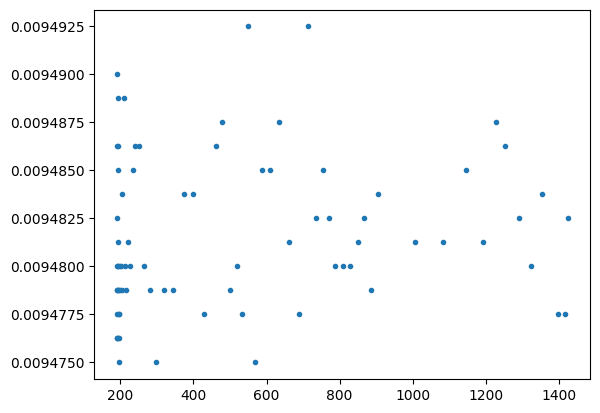

In [18]:
plt.plot(temps, Periods, linestyle='', marker='.')